In [7]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import os

In [8]:
X_scaled = np.load("../results/pca_outputs/scaled_data.npy")

X_scaled[:5]

array([[-1.40198032, -1.02834389, -1.36514142,  0.54794282, -0.4203895 ,
        -0.33361745,  1.44984416, -0.55206138, -1.62105876, -1.41971845,
         1.2705678 ],
       [-1.20303269,  0.97243734,  0.05716833, -0.63732391,  0.35118263,
        -0.78034795, -1.29348327, -1.24104994,  0.4842793 , -0.64711586,
         1.2705678 ],
       [-1.00408506, -1.02834389, -1.36514142,  1.04180396, -0.4203895 ,
        -0.24199582, -0.60765141,  0.13692719, -0.21750005,  0.12548673,
        -0.12049575],
       [-1.60092795,  0.97243734, -0.65398654,  1.14057618, -0.4203895 ,
        -0.52897507, -1.29348327, -0.55206138, -0.91927941, -0.64711586,
        -0.12049575],
       [-1.26934857, -1.02834389, -0.65398654,  1.73320955,  0.35118263,
        -1.19982114, -1.29348327,  0.82591575,  1.18605866, -1.41971845,
        -0.81602752]])

In [9]:
kmeans = KMeans(n_clusters=4, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

clusters[:10]

array([2, 1, 1, 1, 1, 2, 1, 3, 0, 3], dtype=int32)

In [10]:
df = pd.read_csv("../data/processed/processed_customer_data.csv")

df.head()

,Age,Gender,Education Level,Geographic Information,Occupation,Income Level,Interactions with Customer Service,Insurance Products Owned,Preferred Contact Time,Preferred Language,Segmentation Group
0,-1.401980,-1.028344,-1.365141,0.547943,-0.420389,-0.333617,1.449844,-0.552061,-1.621059,-1.419718,1.270568
1,-1.203033,0.972437,0.057168,-0.637324,0.351183,-0.780348,-1.293483,-1.241050,0.484279,-0.647116,1.270568
2,-1.004085,-1.028344,-1.365141,1.041804,-0.420389,-0.241996,-0.607651,0.136927,-0.217500,0.125487,-0.120496
3,-1.600928,0.972437,-0.653987,1.140576,-0.420389,-0.528975,-1.293483,-0.552061,-0.919279,-0.647116,-0.120496
4,-1.269349,-1.028344,-0.653987,1.733210,0.351183,-1.199821,-1.293483,0.825916,1.186059,-1.419718,-0.816028


In [11]:
df["Cluster"] = clusters

df.head()

,Age,Gender,Education Level,Geographic Information,Occupation,Income Level,Interactions with Customer Service,Insurance Products Owned,Preferred Contact Time,Preferred Language,Segmentation Group,Cluster
0,-1.401980,-1.028344,-1.365141,0.547943,-0.420389,-0.333617,1.449844,-0.552061,-1.621059,-1.419718,1.270568,2
1,-1.203033,0.972437,0.057168,-0.637324,0.351183,-0.780348,-1.293483,-1.241050,0.484279,-0.647116,1.270568,1
2,-1.004085,-1.028344,-1.365141,1.041804,-0.420389,-0.241996,-0.607651,0.136927,-0.217500,0.125487,-0.120496,1
3,-1.600928,0.972437,-0.653987,1.140576,-0.420389,-0.528975,-1.293483,-0.552061,-0.919279,-0.647116,-0.120496,1
4,-1.269349,-1.028344,-0.653987,1.733210,0.351183,-1.199821,-1.293483,0.825916,1.186059,-1.419718,-0.816028,1


In [12]:
os.makedirs("../results/cluster_plots", exist_ok=True)

In [13]:
df.to_csv("../results/cluster_plots/customer_clusters.csv", index=False)

print("Clusters saved successfully")

Clusters saved successfully


In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/featured_customer_data.csv")
df.head()

,Age,Gender,Education Level,Geographic Information,Occupation,Income Level,Interactions with Customer Service,Insurance Products Owned,Preferred Contact Time,Preferred Language,Segmentation Group,Engagement Score,Income per Product,Age Group,High Value
0,-1.401980,-1.028344,-1.365141,0.547943,-0.420389,-0.333617,1.449844,-0.552061,-1.621059,-1.419718,1.270568,-0.800403,-0.744784,0,0
1,-1.203033,0.972437,0.057168,-0.637324,0.351183,-0.780348,-1.293483,-1.241050,0.484279,-0.647116,1.270568,1.605277,3.237287,0,0
2,-1.004085,-1.028344,-1.365141,1.041804,-0.420389,-0.241996,-0.607651,0.136927,-0.217500,0.125487,-0.120496,-0.083204,-0.212851,0,0
3,-1.600928,0.972437,-0.653987,1.140576,-0.420389,-0.528975,-1.293483,-0.552061,-0.919279,-0.647116,-0.120496,0.714082,-1.180910,0,0
4,-1.269349,-1.028344,-0.653987,1.733210,0.351183,-1.199821,-1.293483,0.825916,1.186059,-1.419718,-0.816028,-1.068308,-0.657107,0,0


In [2]:
X = df.select_dtypes(include=['int64', 'float64'])

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = clusters

df.head()

,Age,Gender,Education Level,Geographic Information,Occupation,Income Level,Interactions with Customer Service,Insurance Products Owned,Preferred Contact Time,Preferred Language,Segmentation Group,Engagement Score,Income per Product,Age Group,High Value,KMeans_Cluster
0,-1.401980,-1.028344,-1.365141,0.547943,-0.420389,-0.333617,1.449844,-0.552061,-1.621059,-1.419718,1.270568,-0.800403,-0.744784,0,0,2
1,-1.203033,0.972437,0.057168,-0.637324,0.351183,-0.780348,-1.293483,-1.241050,0.484279,-0.647116,1.270568,1.605277,3.237287,0,0,2
2,-1.004085,-1.028344,-1.365141,1.041804,-0.420389,-0.241996,-0.607651,0.136927,-0.217500,0.125487,-0.120496,-0.083204,-0.212851,0,0,2
3,-1.600928,0.972437,-0.653987,1.140576,-0.420389,-0.528975,-1.293483,-0.552061,-0.919279,-0.647116,-0.120496,0.714082,-1.180910,0,0,2
4,-1.269349,-1.028344,-0.653987,1.733210,0.351183,-1.199821,-1.293483,0.825916,1.186059,-1.419718,-0.816028,-1.068308,-0.657107,0,0,2


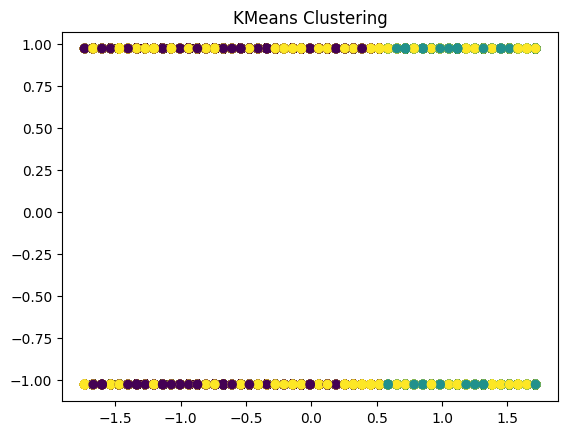

In [5]:
import matplotlib.pyplot as plt

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters)
plt.title("KMeans Clustering")
plt.show()

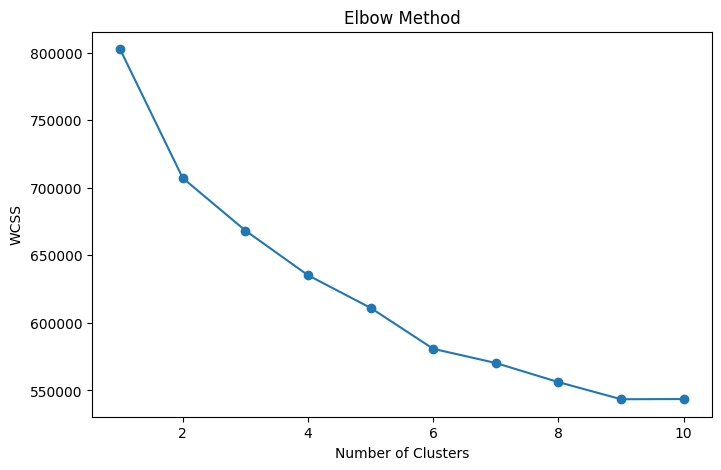

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [7]:
from sklearn.metrics import silhouette_score

for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K = {k}, Silhouette Score = {score}")

K = 2, Silhouette Score = 0.1181231658451263
K = 3, Silhouette Score = 0.09611879871794493
K = 4, Silhouette Score = 0.1063833594190352
K = 5, Silhouette Score = 0.09980208576116982


In [ ]:
#CLUSTER SELECTION
Optimal Cluster Selection:

The Elbow Method indicates a bend at K = 2.

Silhouette Scores for different values of K were evaluated, and the highest score was observed at K = 2 (0.118), indicating it is the best among the tested values.

However, the overall silhouette scores are relatively low, suggesting that the clusters are not very well separated.

Despite this, K = 2 is selected as the optimal number of clusters based on comparative performance.

In [ ]:
#METRIC 
#EVALUATION METHOD
from sklearn.metrics import davies_bouldin_score

for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = davies_bouldin_score(X_scaled, labels)
    print(f"K = {k}, Davies-Bouldin Score = {score}")

K = 2, Davies-Bouldin Score = 2.6906421548477497
K = 3, Davies-Bouldin Score = 2.5920279875510723
K = 4, Davies-Bouldin Score = 2.6744865582990185
K = 5, Davies-Bouldin Score = 2.5493190414669993


In [ ]:
#FINAL CLUSTER SELECTION
Optimal Cluster Selection:

The Elbow Method indicates a clear bend at K = 2.

Silhouette Score is highest at K = 2 (0.118), suggesting relatively better cluster separation compared to other values.

Davies–Bouldin Index is lowest at K = 5; however, since both Elbow Method and Silhouette Score strongly support K = 2, it is selected as the optimal number of clusters.

Thus, K = 2 is chosen for final clustering.